In [2]:
# single-cell analysis package
library(Seurat)
library(harmony)

# plotting and data science packages
library(readr)
library(repr)
library(readxl)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

In [3]:
# Data Location and files
count_data_file <- "./../data/GSE165897_UMIcounts_HGSOC.tsv.gz"
cell_info_file <- './../data/GSE165897_cellInfo_HGSOC.tsv'

In [4]:
# Readd Metadata
metadata <- read_tsv(cell_info_file, show_col_types = FALSE)
metadata <- as.data.frame(metadata)
rownames(metadata) <- metadata$cell
print(dim(metadata))
print(table(metadata$patient_id))
print(table(metadata$cell_type))
print(table(metadata$treatment_phase))

[1] 51786    10

EOC1005  EOC136  EOC153  EOC227    EOC3  EOC349  EOC372  EOC443  EOC540  EOC733 
   4359    6103    3781    4193    5645    2954    5382    6585    3964    5819 
  EOC87 
   3001 

    EOC  Immune Stromal 
   8806   34935    8045 

      post-NACT treatment-naive 
          30025           21761 


In [5]:
scRNAseq_raw <- data.table::fread( count_data_file, index = "V1")
scRNAseq_raw <- as.data.frame(scRNAseq_raw)
print(dim(scRNAseq_raw))
rownames(scRNAseq_raw) <- scRNAseq_raw$V1
scRNAseq_raw$V1 <- NULL
seuratObj <- CreateSeuratObject(counts = scRNAseq_raw, project = "HGSOC")
print(seuratObj)

[1] 32847 51787


Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: RNA (32847 features, 0 variable features)
 1 layer present: counts


In [6]:
print(table(rownames(seuratObj@meta.data) == rownames(metadata)))


 TRUE 
51786 


In [7]:
# Add the metadata - cell type annotation
seuratObj <- AddMetaData(object = seuratObj, metadata = metadata)
seuratObj

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: RNA (32847 features, 0 variable features)
 1 layer present: counts

In [8]:
seuratObj <- NormalizeData(seuratObj, verbose = FALSE)
seuratObj <- FindVariableFeatures(seuratObj, selection.method = "vst", nfeatures = 3000, verbose = FALSE)
seuratObj <- ScaleData(seuratObj, features = VariableFeatures(seuratObj), verbose = FALSE)
print(seuratObj)

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: RNA (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data


In [9]:
seuratObj <- RunPCA(seuratObj, npcs = 50, verbose = FALSE)
seuratObj <- RunHarmony(seuratObj, group.by.vars=c('patient_id'))
seuratObj <- RunUMAP(seuratObj, reduction = "harmony", dims = 1:30, verbose = FALSE)
seuratObj <- RunTSNE(seuratObj, reduction = "harmony", dims = 1:30, verbose = FALSE)

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [10]:
seuratObj <- FindNeighbors(seuratObj, reduction = "harmony", dims = 1:30, verbose = FALSE)
seuratObj <- FindClusters(seuratObj, resolution = 0.5, verbose = FALSE)
print(seuratObj)

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: RNA (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne


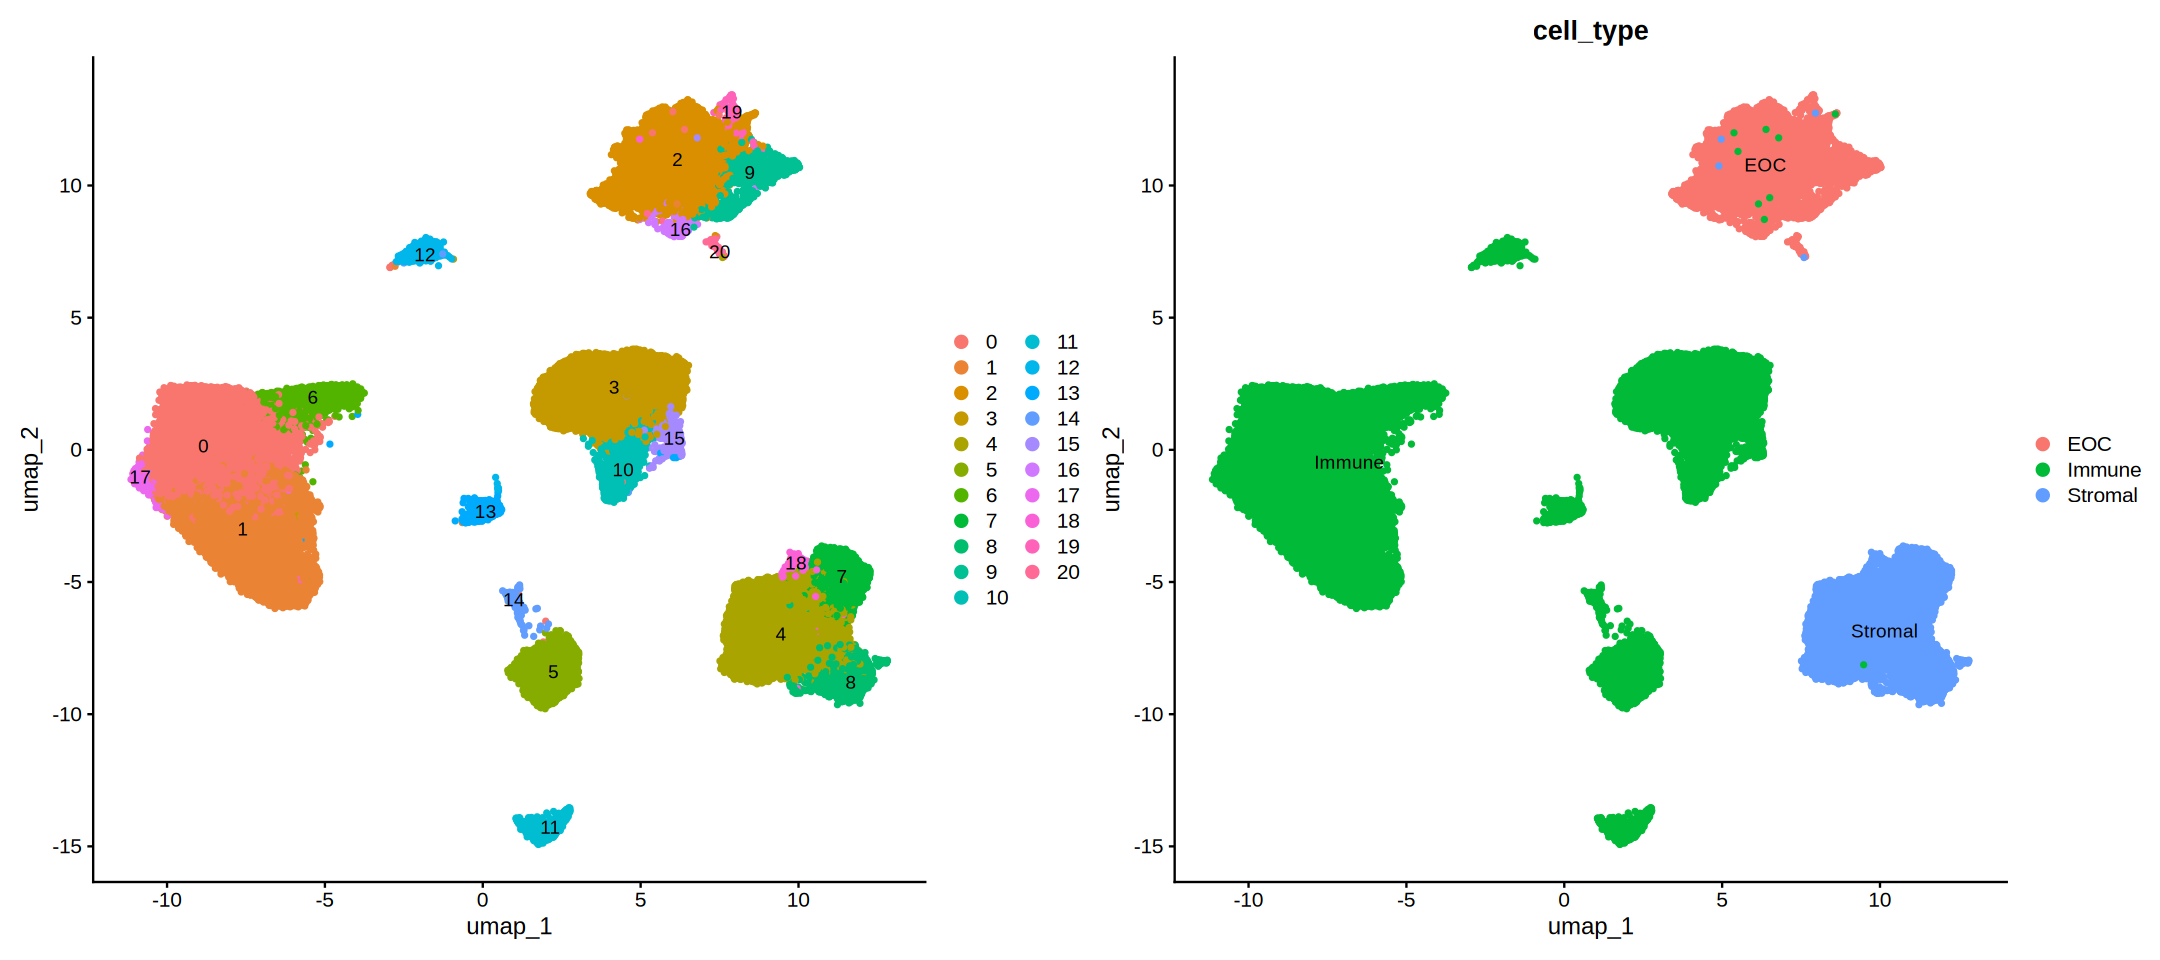

In [11]:
# show the UMAP and tsne
options(repr.plot.height = 8, repr.plot.width = 18)
p1 <- DimPlot(seuratObj, reduction = "umap", label = TRUE,  pt.size = 1)
p2 <- DimPlot(seuratObj, reduction = "umap", label = TRUE, group.by = 'cell_type', pt.size = 1, )
p1 + p2

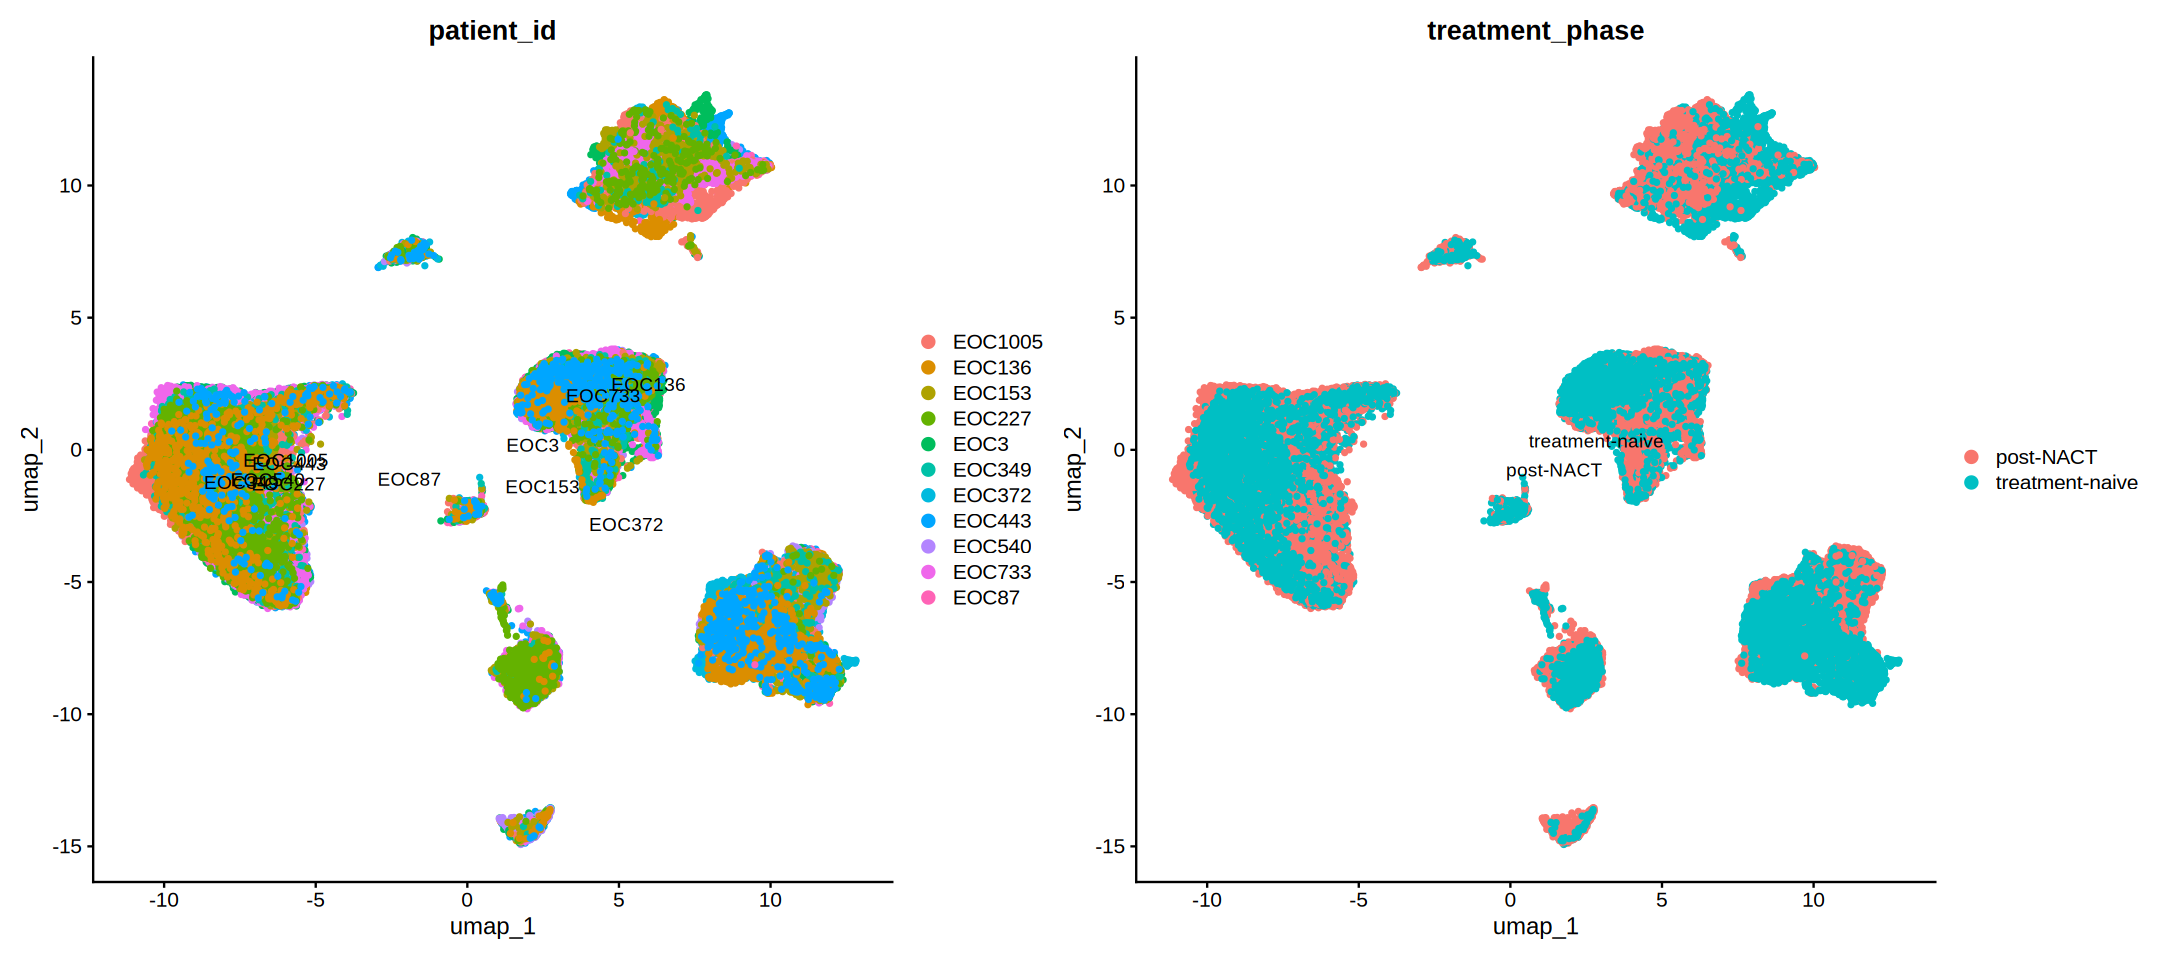

In [12]:
# show the UMAP and tsne
options(repr.plot.height = 8, repr.plot.width = 18)
p1 <- DimPlot(seuratObj, reduction = "umap", label = TRUE, group.by = 'patient_id', pt.size = 1)
p2 <- DimPlot(seuratObj, reduction = "umap", label = TRUE, group.by = 'treatment_phase', pt.size = 1, )
p1 + p2

In [13]:
saveRDS(seuratObj,  "./HGSOC_scRNAseq_seurat_processed.rds")